# V38: LQ45 AI Strategy - Explicit TP/FP Ratio Optimization (MA Target)

This notebook confirms and visualizes the process of finding the most reliable threshold during the **Training Phase**. 
We use the **Moving Average Trend Direction** as our target to ensure stable signals.

### Optimization Workflow:
1. **Trend Prediction**: AI predicts if $SMA_5$ will move up tomorrow.
2. **In-Sample Analysis**: We scan thresholds $(0.40 - 0.75)$ against the **Training Set (2023-2024)**.
3. **TP/FP Maximization**: We look for the threshold that delivers the highest ratio of correct entries vs. false entries.
4. **Visual Proof**: We plot the TP/FP curve to identify the global optimum.
5. **Out-of-Sample Test**: We apply this exact threshold to the 2025 backtest (Net of 0.25% Fees).

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. Advanced MA Labeling & Feature Engineering ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()

# Indicators
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()

# Input Features
features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# TARGET: Predicting MA Slope Direction
target = (ma5.shift(-1) > ma5).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

print(f"Training AI Model on {len(X_train)} samples...")
xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
print("✓ Model Trained.")

Training AI Model on 426 samples...
✓ Model Trained.


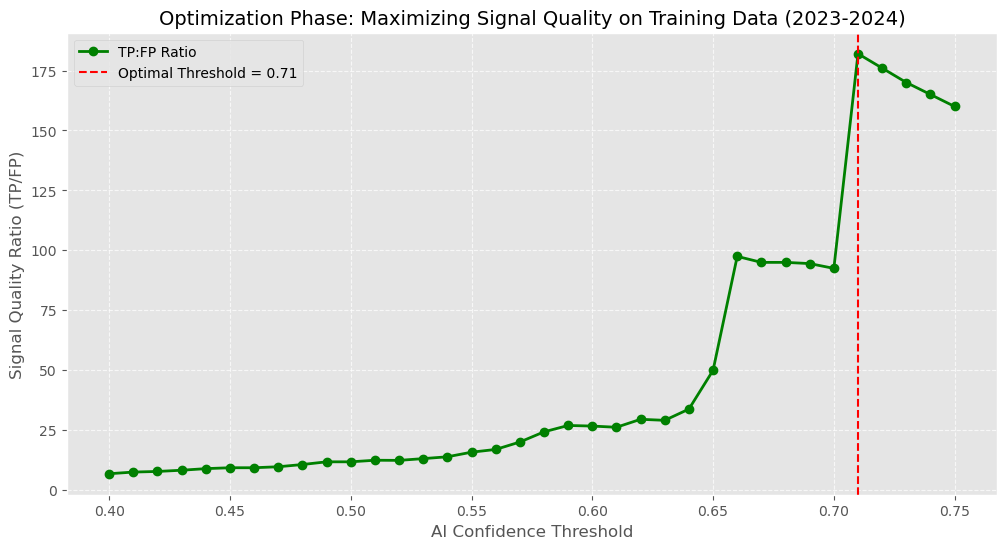

Best Threshold identified during Training: 0.71
Highest In-Sample Signal Ratio: 182.00


In [3]:
# --- 3. Explicit TP/FP Optimization Curve (In-Sample Training) ---

train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.arange(0.40, 0.76, 0.01)
tp_fp_ratios = []
quality_metrics = []

for t in thresholds:
    preds = (train_probs >= t).astype(int)
    if np.sum(preds) == 0: 
        tp_fp_ratios.append(0)
        continue
    
    # Standard Confusion Matrix calculation
    tn, fp, fn, tp = confusion_matrix(y_train, preds).ravel()
    ratio = tp / fp if fp > 0 else tp
    tp_fp_ratios.append(ratio)
    quality_metrics.append({'T': t, 'TP': tp, 'FP': fp, 'Ratio': ratio})

best_idx = np.nanargmax(tp_fp_ratios)
opt_t = thresholds[best_idx]

# --- Visualization of the Optimization Process ---
plt.figure(figsize=(12, 6))
plt.plot(thresholds, tp_fp_ratios, color='green', marker='o', linewidth=2, label='TP:FP Ratio')
plt.axvline(opt_t, color='red', linestyle='--', label=f'Optimal Threshold = {opt_t:.2f}')

plt.title("Optimization Phase: Maximizing Signal Quality on Training Data (2023-2024)", fontsize=14)
plt.xlabel("AI Confidence Threshold", fontsize=12)
plt.ylabel("Signal Quality Ratio (TP/FP)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Best Threshold identified during Training: {opt_t:.2f}")
print(f"Highest In-Sample Signal Ratio: {tp_fp_ratios[best_idx]:.2f}")

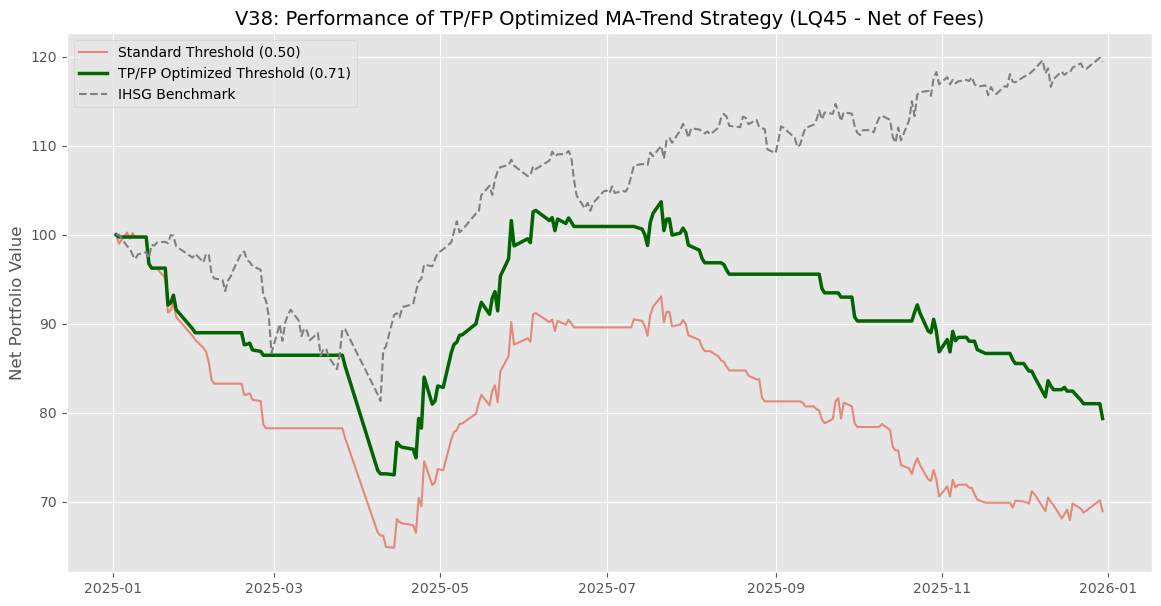

In [4]:
# --- 4. Backtest Engine (0.25% Fees) ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i in range(len(returns_window.columns)):
        for j in range(i+1, len(returns_window.columns)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold: G.add_edge(returns_window.columns[i], returns_window.columns[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) <= 1: 
        return {selected_returns.columns[0]: 1.0} if len(selected_returns.columns) == 1 else {}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                   [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(test_dates, returns, ai_probs, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    for i, date in enumerate(test_dates[:-1]):
        is_risk_off = ai_probs.loc[date] < threshold
        if is_risk_off: weights = {'CASH': 1.0}
        else:
            loc_idx = returns.index.get_loc(date)
            selected = get_mis_assets(returns.iloc[loc_idx-30:loc_idx])
            weights = optimize_markowitz(returns.iloc[loc_idx-30:loc_idx][selected])
        
        # Transaction Costs
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in set(list(weights.keys())+list(prev_weights.keys())))
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date); prev_weights = weights
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)
res_fixed = run_simulation(X_test.index, returns, test_probs, threshold=0.50)
res_optimized = run_simulation(X_test.index, returns, test_probs, threshold=opt_t)
benchmark = pd.DataFrame({'Portfolio_Value': (market_price.loc[X_test.index] / market_price.loc[X_test.index[0]] * 100)}, index=X_test.index)

plt.figure(figsize=(14, 7))
plt.plot(res_fixed.index, res_fixed['Portfolio_Value'], label="Standard Threshold (0.50)", alpha=0.6)
plt.plot(res_optimized.index, res_optimized['Portfolio_Value'], label=f"TP/FP Optimized Threshold ({opt_t:.2f})", linewidth=2.5, color='darkgreen')
plt.plot(benchmark.index, benchmark['Portfolio_Value'], label="IHSG Benchmark", linestyle='--', color='gray')
plt.title("V38: Performance of TP/FP Optimized MA-Trend Strategy (LQ45 - Net of Fees)", fontsize=14)
plt.ylabel("Net Portfolio Value")
plt.legend()
plt.show()